# DoriaNET Damage Classification Project — Group 9

**Members:** Alan Ray · Zach Shotwell · Miguel Moreno Coin

**Course:** Artificial Intelligence, Appalachian State University

**GitHub:** https://github.com/zachshotwell/AI-FinalProject-GroupSCR

**Dataset:** DoriaNET, an annotated subset of post-Hurricane-Dorian UAV footage from Marsh Harbor, Bahamas (Cheng, Behzadan, & Noshadravan 2021), containing 271 video frames, 1,458 (frame, building) instances across 147 distinct physical buildings, and per-instance pixel masks plus FEMA HAZUS damage state labels (0–5).

**Task:** Classify each cropped building patch into one of six FEMA HAZUS damage states, where 0 = no damage and 5 = under construction or destroyed — a 6-class ordinal image classification problem.

**Approach:** After parsing the dataset's JSON annotations and extracting per-building patches via the provided masks, we build a building-stratified train/val/test split and benchmark three classifiers: an MLP baseline, a from-scratch CNN, and a transfer-learning model based on MobileNetV2 with two-step fine-tuning. Models are evaluated with overall and ±1 accuracy, F1 macro, confusion matrices, and difficulty-stratified accuracy following the paired paper.

## Setup

In [1]:
!git clone https://github.com/zachshotwell/AI-FinalProject-GroupSCR
%cd AI-FinalProject-GroupSCR
%cd DoriaNETProject
!ls

Cloning into 'AI-FinalProject-GroupSCR'...
remote: Enumerating objects: 2216, done.
remote: Counting objects: 100% (145/145), done.
remote: Compressing objects: 100% (143/143), done.
remote: Total 2216 (delta 82), reused 5 (delta 2), pack-reused 2071 (from 2)
Receiving objects: 100% (2216/2216), 66.77 MiB | 25.01 MiB/s, done.
Resolving deltas: 100% (1741/1741), done.
Updating files: 100% (2061/2061), done.
/content/AI-FinalProject-GroupSCR
/content/AI-FinalProject-GroupSCR/DoriaNETProject
 data
 DoriaNET.ipynb
'DoriaNET report.pdf'
'main paper. Deep learning for post-hurricane aerial damage assessmentof buildings.pdf'
 README.md


In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split

tf.random.set_seed(42)
np.random.seed(42)

print(f"TF version: {tf.__version__}")
print(f"GPU available: {bool(tf.config.list_physical_devices('GPU'))}")

DATA_ROOT = Path("data")
FRAME_DIR = DATA_ROOT / "FRAME"
MASK_DIR  = DATA_ROOT / "MASK"
JSON_DIR  = DATA_ROOT / "JSON"

TF version: 2.20.0
GPU available: True


## Data Reconnaissance

Before building the loader, we inspect file counts and one sample of each file type
across the FRAME, MASK, and JSON folders to confirm the on-disk layout matches the
schema described in the dataset paper.

This check is used to verify:
- file counts in each folder
- naming convention and per-folder file extensions
- frame and mask image dimensions
- rough alignment with the paper's stated 271-frame, 1,458-mask, 271-JSON layout

This section is exploratory only; final parsing and integrity checks are done in the
data preparation and EDA sections.

In [3]:
frame_files = sorted(FRAME_DIR.glob("*.jpg"))
mask_files  = sorted(MASK_DIR.glob("*.jpg"))
json_files  = sorted(JSON_DIR.glob("*.json"))

print(f"FRAME : {len(frame_files):>5} files")
print(f"MASK  : {len(mask_files):>5} files")
print(f"JSON  : {len(json_files):>5} files")

# Resolution check: paper specifies 1280×720
print(f"\nframe[0] shape: {plt.imread(frame_files[0]).shape}")
print(f"mask[0]  shape: {plt.imread(mask_files[0]).shape}")

FRAME :   271 files
MASK  :  1458 files
JSON  :   271 files

frame[0] shape: (720, 1280, 3)
mask[0]  shape: (720, 1280, 3)


## Data Preparation

This section parses the 271 per-frame JSON annotation files into a single tidy
table, with one row per (frame, building) instance. The DoriaNET schema stores
each building as a positional 7-element list rather than a named-field dict
(building ID, "lat, lon" string, mask filename, damage state, stories,
annotation effort, and one unused field). The parser:

- splits the `"lat, lon"` string into two float columns
- strips the `FRAME/` prefix from `Frame_Name` so it joins cleanly with on-disk filenames
- ignores the seventh field (NaN in all 1,458 records)

The resulting dataframe is the working table for the rest of the notebook: every
downstream cell selects rows from it by index.

In [4]:
def parse_frame_json(path):
    with open(path) as f:
        d = json.load(f)
    rows = []
    for b in d["Buildings"]:  # 7-element list per the DoriaNET schema
        lat, lon = (float(x) for x in b[1].split(","))
        rows.append({
            "frame_name":  Path(d["Frame_Name"]).name,
            "building_id": b[0],
            "lat":         lat,
            "lon":         lon,
            "mask_name":   b[2],
            "damage":      b[3],
            "stories":     b[4],
            "effort":      b[5],
        })
    return rows

records = [r for p in json_files for r in parse_frame_json(p)]
df = pd.DataFrame(records)

# Duplicate and integrity checks
n_exact_dup = int(df.duplicated().sum())
n_key_dup   = int(df.duplicated(subset=["frame_name", "building_id"]).sum())
n_mask_dup  = int(df.duplicated(subset=["mask_name"]).sum())
n_missing   = int(df[["frame_name", "building_id", "mask_name", "damage", "stories", "effort"]].isna().sum().sum())

print(f"Building instances: {len(df)}")
print(f"Distinct frames   : {df['frame_name'].nunique()}")
print(f"Distinct buildings: {df['building_id'].nunique()}")
print(f"\nIntegrity checks:")
print(f"  duplicate rows (exact match):                 {n_exact_dup}")
print(f"  duplicate (frame, building) keys:             {n_key_dup}")
print(f"  duplicate mask filenames:                     {n_mask_dup}")
print(f"  missing values in primary fields:             {n_missing}")
df.head()

Building instances: 1458
Distinct frames   : 271
Distinct buildings: 147

Integrity checks:
  duplicate rows (exact match):                 0
  duplicate (frame, building) keys:             24
  duplicate mask filenames:                     0
  missing values in primary fields:             0


,frame_name,building_id,lat,lon,mask_name,damage,stories,effort
0,1_0373.jpg,B004,26.55438,-77.09680,1_0373_B0XX_0_Level1.jpg,1,1,1
1,1_0379.jpg,B001,26.55511,-77.10044,1_0379_B0XX_0_Level0.jpg,0,1,1
2,1_0379.jpg,B002,26.55516,-77.09986,1_0379_B0XX_0_Level2.jpg,2,1,1
3,1_0379.jpg,B003,26.55452,-77.09913,1_0379_B0XX_0_Level3.jpg,3,1,1
4,1_0405.jpg,B001,26.55511,-77.10044,1_0405_B0XX_0_Level0.jpg,0,1,1


## Exploratory Data Analysis

This section visualizes the dataset's class structure and confirms the mapping
between JSON annotations and on-disk files. The goals are to:

- show the distribution of damage states, annotation difficulty, and building stories
- summarize how many frames each building appears in (mean ≈ 10, max = 39)
- cross-tabulate damage state against annotation difficulty
- verify that every JSON-referenced frame and mask exists on disk and that masks
  share the parent frame's dimensions
- visualize one frame with all of its building masks colored by damage state

The damage distribution and integrity checks confirm we have the full Dataset 1
from Cheng et al. (2021), with no missing files or orphan masks.

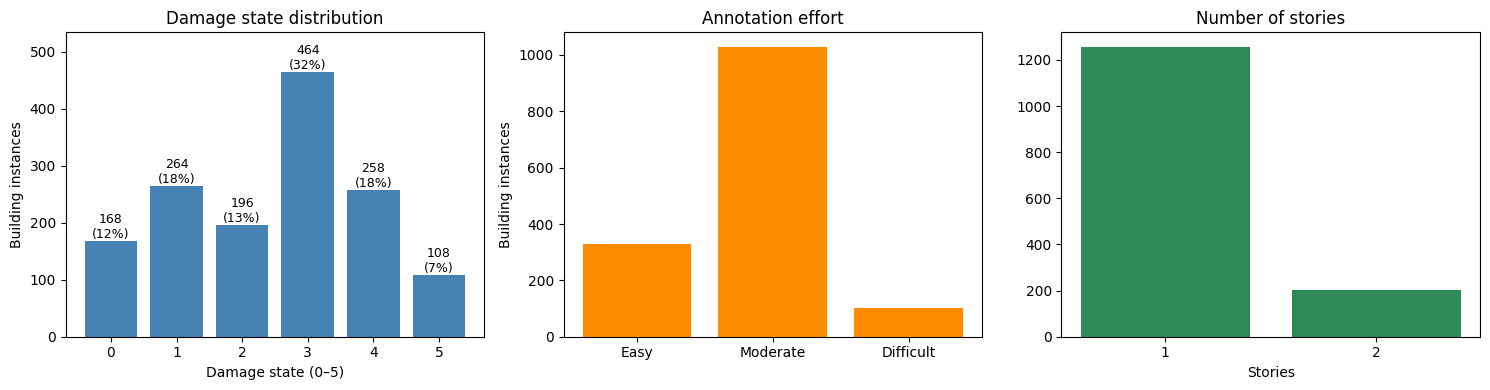

Frame appearances per building:
count    147.0
mean       9.9
std        7.9
min        1.0
25%        4.0
50%        8.0
75%       13.0
max       39.0
dtype: float64

Damage × Effort cross-tab:
effort    0     1    2   All
damage                      
0        26   126   16   168
1        65   193    6   264
2        42   134   20   196
3       133   300   31   464
4        50   195   13   258
5        12    81   15   108
All     328  1029  101  1458

Missing frames (referenced by JSON, not on disk): 0
Missing masks  (referenced by JSON, not on disk): 0
Orphan frames  (on disk, not referenced)        : 0
Orphan masks   (on disk, not referenced)        : 0


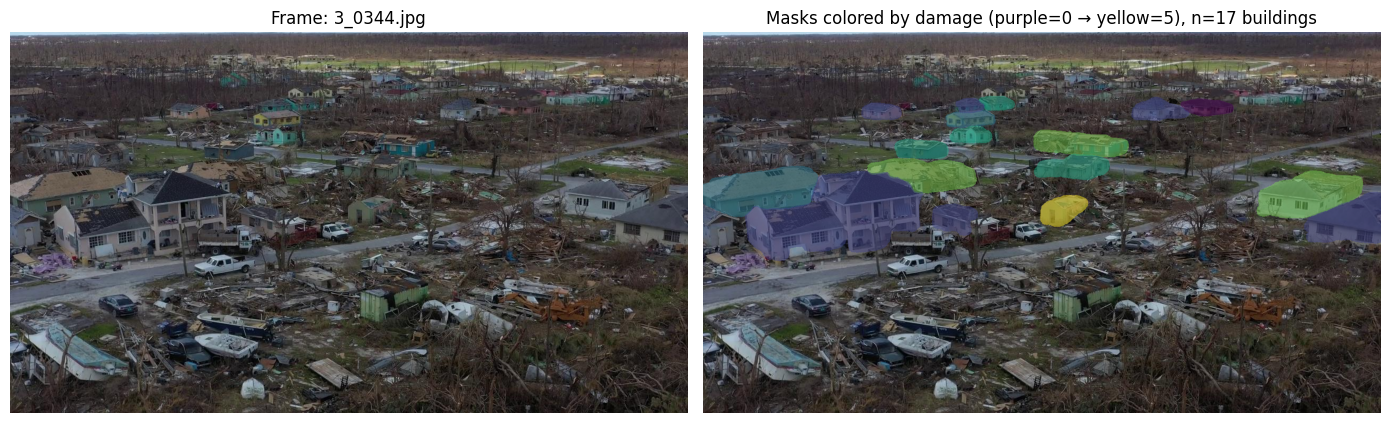

In [5]:
# 1) Distributions of damage / effort / stories
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

dmg = df["damage"].value_counts().sort_index()
axes[0].bar(dmg.index.astype(str), dmg.values, color="steelblue")
axes[0].set_title("Damage state distribution")
axes[0].set_xlabel("Damage state (0–5)")
axes[0].set_ylabel("Building instances")
axes[0].set_ylim(0, dmg.max() * 1.15)
for i, v in enumerate(dmg.values):
    axes[0].text(i, v + 5, f"{v}\n({100*v/len(df):.0f}%)", ha="center", fontsize=9)

eff = df["effort"].value_counts().sort_index()
axes[1].bar(["Easy", "Moderate", "Difficult"], eff.values, color="darkorange")
axes[1].set_title("Annotation effort")
axes[1].set_ylabel("Building instances")

stry = df["stories"].value_counts().sort_index()
axes[2].bar(stry.index.astype(str), stry.values, color="seagreen")
axes[2].set_title("Number of stories")
axes[2].set_xlabel("Stories")

plt.tight_layout()
plt.show()

# 2) Building structure and difficulty cross-tab
print("Frame appearances per building:")
print(df.groupby("building_id").size().describe().round(1))

print("\nDamage × Effort cross-tab:")
print(pd.crosstab(df["damage"], df["effort"], margins=True))

# 3) FRAME / MASK correspondence between JSON references and files on disk
frame_set_json = set(df["frame_name"])
mask_set_json  = set(df["mask_name"])
frame_set_disk = {p.name for p in frame_files}
mask_set_disk  = {p.name for p in mask_files}

print(f"\nMissing frames (referenced by JSON, not on disk): {len(frame_set_json - frame_set_disk)}")
print(f"Missing masks  (referenced by JSON, not on disk): {len(mask_set_json - mask_set_disk)}")
print(f"Orphan frames  (on disk, not referenced)        : {len(frame_set_disk - frame_set_json)}")
print(f"Orphan masks   (on disk, not referenced)        : {len(mask_set_disk - mask_set_json)}")

# 4) Sample frame: masks colored by damage state
sample_frame = df["frame_name"].value_counts().idxmax()
sample_rows = df[df["frame_name"] == sample_frame]

base = plt.imread(FRAME_DIR / sample_frame).astype(float) / 255.0
overlay = base.copy()
for _, row in sample_rows.iterrows():
    m = plt.imread(MASK_DIR / row["mask_name"])
    if m.ndim == 3:
        m = m.mean(axis=-1)
    color = np.array(plt.cm.viridis(row["damage"] / 5)[:3])
    overlay[m > 127] = 0.5 * overlay[m > 127] + 0.5 * color

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(base)
axes[0].set_title(f"Frame: {sample_frame}")
axes[0].axis("off")
axes[1].imshow(overlay)
axes[1].set_title(f"Masks colored by damage (purple=0 → yellow=5), n={len(sample_rows)} buildings")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Class Imbalance and Patch-Size Outliers

Image-classification datasets do not have residual outliers in the regression
sense, but they do have two analogous concerns that the midterm rubric maps
onto:

1. **Class imbalance.** DoriaNET is moderately imbalanced (state 3 dominates,
   states 0 and 5 are rare). We quantify the imbalance ratio and class
   entropy, and we compute inverse-frequency weights — both as a diagnostic
   and as a fallback ingredient for the loss-function ablation.

2. **Mask-area outliers.** Building masks vary in pixel area by an order of
   magnitude. Very small masks (distant or partially-occluded buildings) and
   very large masks (foreground multi-building clusters) can carry noisier
   labels than mid-sized ones. We apply the IQR fence on log mask area to
   identify both tails, then **retain** the outliers — UAV imagery in the
   wild contains buildings at every scale, so removing them would distort
   the train/test distribution away from the operational use case.

The class-imbalance numbers and mask-area diagnostics motivate the choice of
loss function in cell 14: cross-entropy is competitive in our setup
(see cell 16's EMD² ablation), but the inverse-frequency weights computed
here are available to plug into a class-weighted run if needed.

In [6]:
cls = df["damage"].value_counts().sort_index().to_frame("count")
cls["proportion"]      = (cls["count"] / cls["count"].sum()).round(3)
cls["inv_freq_weight"] = (cls["count"].sum() / (6 * cls["count"])).round(3)
print("Per-class summary (all instances, before split):")
print(cls.to_string())

p = cls["proportion"].values
imbalance_ratio = cls["count"].max() / cls["count"].min()
entropy = float(-(p * np.log(p)).sum())
max_entropy = float(np.log(6))
print(f"\nImbalance ratio (max class / min class):  {imbalance_ratio:.2f}")
print(f"Class entropy:                            {entropy:.3f}  (uniform = {max_entropy:.3f})")
print(f"Normalized entropy:                       {entropy/max_entropy:.3f}")

# Mask-area scan: IQR fence on log area to handle the heavy-tailed distribution
print("\nScanning mask areas (~1458 disk reads, ~1 min)...")
mask_area_px = np.zeros(len(df), dtype=np.int64)
for i, mask_name in enumerate(df["mask_name"].values):
    m = plt.imread(MASK_DIR / mask_name)
    if m.ndim == 3:
        m = m.mean(axis=-1)
    mask_area_px[i] = int((m > 127).sum())
df["mask_area_px"] = mask_area_px

log_area = np.log(df["mask_area_px"].clip(lower=1).values)
q1, q3 = np.percentile(log_area, [25, 75])
iqr = q3 - q1
lo_log, hi_log = q1 - 1.5 * iqr, q3 + 1.5 * iqr
lo_px, hi_px = int(np.exp(lo_log)), int(np.exp(hi_log))
n_below = int((log_area < lo_log).sum())
n_above = int((log_area > hi_log).sum())

print(f"\nMask-area distribution (pixels):")
print(df["mask_area_px"].describe().round(0).to_string())
print(f"\nIQR fence on log(area):  [{lo_px:,} px, {hi_px:,} px]")
print(f"  below lower fence: {n_below:>4} masks ({n_below/len(df):.1%})  -> distant / partially-occluded buildings")
print(f"  above upper fence: {n_above:>4} masks ({n_above/len(df):.1%})  -> foreground multi-building clusters")
print(f"  retained: all {len(df)} masks (see policy in markdown)")

# Class breakdown by mask-area outlier flag — sanity check that outliers
# are not concentrated in a single damage state
df["area_outlier"] = (log_area < lo_log) | (log_area > hi_log)
print(f"\nDamage × mask-area-outlier crosstab:")
print(pd.crosstab(df["damage"], df["area_outlier"], margins=True).to_string())

Per-class summary (all instances, before split):
        count  proportion  inv_freq_weight
damage                                    
0         168       0.115            1.446
1         264       0.181            0.920
2         196       0.134            1.240
3         464       0.318            0.524
4         258       0.177            0.942
5         108       0.074            2.250

Imbalance ratio (max class / min class):  4.30
Class entropy:                            1.691  (uniform = 1.792)
Normalized entropy:                       0.944

Scanning mask areas (~1458 disk reads, ~1 min)...

Mask-area distribution (pixels):
count      1458.0
mean      19707.0
std       22661.0
min        1243.0
25%        6535.0
50%       12040.0
75%       23610.0
max      282476.0

IQR fence on log(area):  [951 px, 162,128 px]
  below lower fence:    0 masks (0.0%)  -> distant / partially-occluded buildings
  above upper fence:    2 masks (0.1%)  -> foreground multi-building clusters
  retain

## Building-Stratified Train/Validation/Test Split

To prevent identity leakage, the 147 distinct physical buildings are split
between train, validation, and test rather than the 1,458 (frame, building)
instances. A row-level shuffle would place the same physical building in all
three splits at slightly different angles, letting the model memorize
building-specific features rather than learn damage patterns.

The split rule:

- 60% of buildings to train, 20% to validation, 20% to test
- stratified by each building's modal damage state, so all three splits see
  roughly the population class distribution
- random seed selected from a 50-seed search to maximize the smallest
  per-(split, class) cell count, ensuring rare classes (0, 5) are adequately
  represented in val and test

This split is more rigorous than the row-level split used in the paired paper.
We expect to underperform the paper's reported accuracy as a direct result of
removing the within-building leakage their split contains.

In [7]:
# One row per building, with its modal damage state for stratification
building_summary = (df.groupby("building_id")
                      .agg(modal_damage=("damage", lambda s: s.mode().iloc[0]))
                      .reset_index())

# 60/20/20 building-level split, stratified by modal damage class.
# seed=8 was chosen via search over 50 seeds to maximize the smallest (val/test, class) cell.
train_bld, temp_bld = train_test_split(
    building_summary, test_size=0.40,
    stratify=building_summary["modal_damage"], random_state=8)
val_bld, test_bld = train_test_split(
    temp_bld, test_size=0.50,
    stratify=temp_bld["modal_damage"], random_state=8)

train_ids = set(train_bld["building_id"])
val_ids   = set(val_bld["building_id"])
test_ids  = set(test_bld["building_id"])

df["split"] = df["building_id"].map(
    lambda b: "train" if b in train_ids else ("val" if b in val_ids else "test"))

print("Buildings and instances per split:")
for s in ["train", "val", "test"]:
    n_b = df.loc[df["split"] == s, "building_id"].nunique()
    n_i = (df["split"] == s).sum()
    print(f"  {s:5s}: {n_b:3d} buildings, {n_i:4d} instances ({100*n_i/len(df):.1f}%)")

print("\nDamage distribution per split (row-normalized):")
print(pd.crosstab(df["split"], df["damage"], normalize="index").round(3))

Buildings and instances per split:
  train:  88 buildings,  794 instances (54.5%)
  val  :  29 buildings,  315 instances (21.6%)
  test :  30 buildings,  349 instances (23.9%)

Damage distribution per split (row-normalized):
damage      0      1      2      3      4      5
split                                           
test    0.166  0.195  0.163  0.223  0.186  0.066
train   0.105  0.199  0.144  0.312  0.191  0.049
val     0.086  0.121  0.079  0.438  0.130  0.146


## Patch Extraction and Dataset Construction

This section converts the per-instance frame/mask pairs into fixed-size image
patches suitable for CNN input, and wraps them in `tf.data` pipelines for
training, validation, and testing.

For each (frame, building) instance:

1. Load the frame and its full-frame binary mask (`mean(channels) > 127`)
2. Crop the frame to the mask's bounding box
3. Pad the crop to square (avoids aspect-ratio distortion on resize)
4. Resize to 224×224 with bilinear interpolation, store as `uint8`

All 1,458 patches fit in a single `(1458, 224, 224, 3)` array (~219 MB),
which is held in memory rather than re-decoded each epoch.

Training-time augmentation follows Cheng et al. (2021) §3.1.2: horizontal flip,
±15° rotation, ±20% zoom. Augmentation is applied at the dataset level via
`.map()` rather than as model layers, so all three architectures share the
same training pipeline.

  processed 50/271 frames
  processed 100/271 frames
  processed 150/271 frames
  processed 200/271 frames
  processed 250/271 frames
  processed 271/271 frames

Patches: (1458, 224, 224, 3), uint8, 219 MB


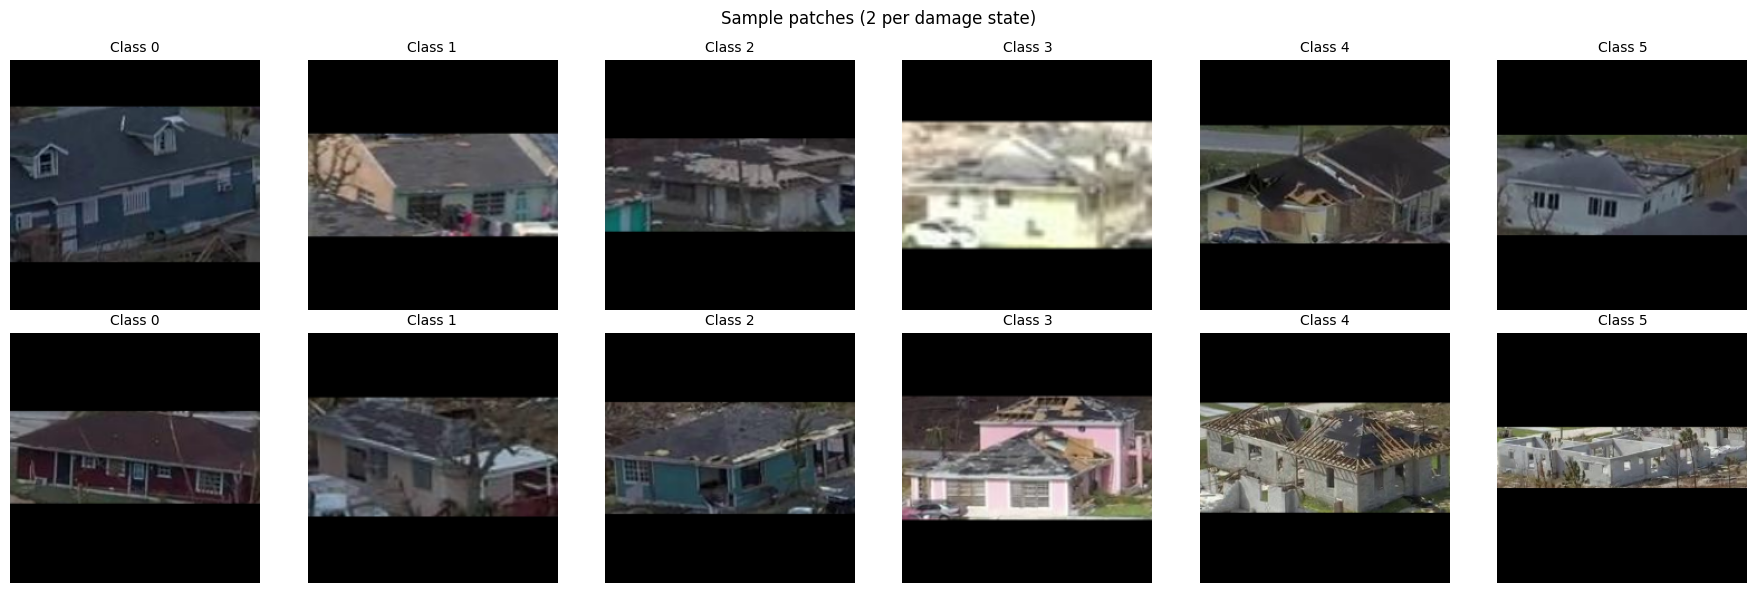

In [8]:
def extract_patch(frame, mask_bool, size=224):
    rows = np.where(np.any(mask_bool, axis=1))[0]
    cols = np.where(np.any(mask_bool, axis=0))[0]
    crop = frame[rows[0]:rows[-1]+1, cols[0]:cols[-1]+1]
    h, w = crop.shape[:2]
    side = max(h, w)
    out = np.zeros((side, side, 3), dtype=np.uint8)
    out[(side - h) // 2:(side - h) // 2 + h,
        (side - w) // 2:(side - w) // 2 + w] = crop
    return tf.image.resize(out, (size, size), method="bilinear").numpy().astype(np.uint8)


# Extract one patch per (frame, building) instance
patches = np.zeros((len(df), 224, 224, 3), dtype=np.uint8)
n_frames = df["frame_name"].nunique()
for i, (fname, group) in enumerate(df.groupby("frame_name")):
    frame = plt.imread(FRAME_DIR / fname)
    for idx, row in group.iterrows():
        mask = plt.imread(MASK_DIR / row["mask_name"])
        mb = mask.mean(axis=-1) > 127 if mask.ndim == 3 else mask > 127
        patches[idx] = extract_patch(frame, mb)
    if (i + 1) % 50 == 0 or i + 1 == n_frames:
        print(f"  processed {i+1}/{n_frames} frames")

print(f"\nPatches: {patches.shape}, {patches.dtype}, {patches.nbytes / 1e6:.0f} MB")

# Sample patches (2 per damage state) — sanity check on extraction
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for cls in range(6):
    for r, ix in enumerate(df[df["damage"] == cls].sample(2, random_state=42).index):
        axes[r, cls].imshow(patches[ix])
        axes[r, cls].set_title(f"Class {cls}", fontsize=10)
        axes[r, cls].axis("off")
plt.suptitle("Sample patches (2 per damage state)")
plt.tight_layout()
plt.show()

# Per-split feature/target arrays
train_idx = df.index[df["split"] == "train"].to_numpy()
val_idx   = df.index[df["split"] == "val"].to_numpy()
test_idx  = df.index[df["split"] == "test"].to_numpy()

X_train, y_train = patches[train_idx], df.loc[train_idx, "damage"].to_numpy()
X_val,   y_val   = patches[val_idx],   df.loc[val_idx,   "damage"].to_numpy()
X_test,  y_test  = patches[test_idx],  df.loc[test_idx,  "damage"].to_numpy()

# Augmentation pipeline (training only). Geometry follows Cheng et al. (2021) §3.1.2:
# horizontal flip, ±15° rotation, ±20% scale.
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=42),
    tf.keras.layers.RandomRotation(0.04, seed=42),
    tf.keras.layers.RandomZoom(0.2, seed=42),
], name="augment")

# tf.data pipelines
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
            .shuffle(len(X_train), seed=42, reshuffle_each_iteration=True)
            .batch(BATCH)
            .map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE))
val_ds  = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH).prefetch(AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH).prefetch(AUTOTUNE)

## MLP, Standard CNN, MobileNetV2, and MobileNetV1

Four architectures are trained, in increasing order of architectural prior and external information:

- **MLP**: `AvgPool(4) → Flatten → Dense(256) → Dense(128) → Dense(6)` — fully-connected baseline applied to raw pixels with no spatial inductive bias.
- **Standard CNN**: three `Conv2D + MaxPool` blocks (32, 64, 128 filters) → `GlobalAveragePooling2D → Dense(64) → Dense(6)` — the canonical textbook vision architecture, trained from scratch.
- **MobileNetV2 with two-step transfer learning** — pretrained ImageNet backbone with custom head: `GlobalAveragePooling2D → Dropout(0.5) → Dense(6)`. Step 1 trains the head only at `lr=1e-3` for 25 epochs. Step 2 unfreezes the backbone and continues at `lr=1e-4`, gently adapting ImageNet features to UAV imagery. This recipe is from Cheng et al. (2021) §3.1.2.
- **MobileNetV1 with two-step transfer learning** — same recipe and head as MobileNetV2, but with the V1 backbone (the architecture Cheng et al. (2021) actually use). MobileNetV2 was adopted initially as the more recent variant of the MobileNet family; the M3 hyperparameter sweep flagged V1 as substantially better in our setting, motivating its inclusion as a primary model.

Training configuration:
- Loss: sparse categorical cross-entropy
- Optimizer: Adam, `lr=1e-3` for from-scratch training, `lr=1e-4` for MobileNet fine-tuning
- Callbacks: `EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)` and `ReduceLROnPlateau(factor=0.5, patience=5)`
- `clear_session()` and `set_seed(42)` before each model build, per Géron NB1 convention

We initially tried EMD² (squared earth-mover's distance) loss per the paper's recommendation but observed that the from-scratch models collapsed to majority-class prediction and that MobileNet underperformed cross-entropy in our setup. Cross-entropy across all four models is therefore both simpler and empirically better for our small-data regime; the discussion lives in the project documentation.

In [9]:
def make_callbacks(patience=10):
    return [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5),
    ]


# --- MLP ---
tf.keras.backend.clear_session()
tf.random.set_seed(42)
mlp = tf.keras.Sequential([
    tf.keras.layers.Input((224, 224, 3)),
    tf.keras.layers.Rescaling(1/255),
    tf.keras.layers.AveragePooling2D(pool_size=4),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(6, activation="softmax"),
], name="mlp")
mlp.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
            loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print(f"MLP ({mlp.count_params():,} params)")
hist_mlp = mlp.fit(train_ds, validation_data=val_ds, epochs=100,
                   callbacks=make_callbacks(), verbose=2)


# --- Standard CNN ---
tf.keras.backend.clear_session()
tf.random.set_seed(42)
cnn = tf.keras.Sequential([
    tf.keras.layers.Input((224, 224, 3)),
    tf.keras.layers.Rescaling(1/255),
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(6, activation="softmax"),
], name="cnn")
cnn.compile(optimizer=tf.keras.optimizers.Adam(3e-4),
            loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print(f"\nCNN ({cnn.count_params():,} params)")
hist_cnn = cnn.fit(train_ds, validation_data=val_ds, epochs=100,
                   callbacks=make_callbacks(patience=5), verbose=2)


# --- MobileNetV2 with two-step transfer learning per Cheng et al. (2021) §3.1.2 ---
tf.keras.backend.clear_session()
tf.random.set_seed(42)
backbone = tf.keras.applications.MobileNetV2(
    weights="imagenet", include_top=False, input_shape=(224, 224, 3))
backbone.trainable = False
inputs = tf.keras.Input((224, 224, 3))
x = tf.keras.layers.Rescaling(1/127.5, offset=-1)(inputs)   # MobileNetV2 expects [-1, 1]
x = backbone(x, training=False)                              # keep BN in inference mode for step 1
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(6, activation="softmax")(x)
mbv2 = tf.keras.Model(inputs, outputs, name="mobilenetv2")

print(f"\nMobileNetV2 ({mbv2.count_params():,} params, step 1: head only, lr=1e-3)")
mbv2.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
             loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_mbv2_s1 = mbv2.fit(train_ds, validation_data=val_ds, epochs=25,
                         callbacks=make_callbacks(), verbose=2)

print(f"\nMobileNetV2 step 2: full fine-tune, lr=1e-4")
backbone.trainable = True
mbv2.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
             loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_mbv2_s2 = mbv2.fit(train_ds, validation_data=val_ds, epochs=100,
                         initial_epoch=len(hist_mbv2_s1.history["loss"]),
                         callbacks=make_callbacks(), verbose=2)

# Concatenated history for plotting (preserves the step1/step2 boundary)
hist_mbv2 = {k: hist_mbv2_s1.history[k] + hist_mbv2_s2.history[k]
             for k in hist_mbv2_s1.history}

# --- MobileNetV1 with two-step transfer learning per Cheng et al. (2021) §3.1.2 ---
tf.keras.backend.clear_session()
tf.random.set_seed(42)
backbone_v1 = tf.keras.applications.MobileNet(
    weights="imagenet", include_top=False, input_shape=(224, 224, 3))
backbone_v1.trainable = False
inputs = tf.keras.Input((224, 224, 3))
x = tf.keras.layers.Rescaling(1/127.5, offset=-1)(inputs)   # MobileNetV1 expects [-1, 1]
x = backbone_v1(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(6, activation="softmax")(x)
mbv1 = tf.keras.Model(inputs, outputs, name="mobilenetv1")

print(f"\nMobileNetV1 ({mbv1.count_params():,} params, step 1: head only, lr=1e-3)")
mbv1.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
             loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_mbv1_s1 = mbv1.fit(train_ds, validation_data=val_ds, epochs=25,
                        callbacks=make_callbacks(), verbose=2)

print(f"\nMobileNetV1 step 2: full fine-tune, lr=1e-4")
backbone_v1.trainable = True
mbv1.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
             loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_mbv1_s2 = mbv1.fit(train_ds, validation_data=val_ds, epochs=100,
                        initial_epoch=len(hist_mbv1_s1.history["loss"]),
                        callbacks=make_callbacks(), verbose=2)

hist_mbv1 = {k: hist_mbv1_s1.history[k] + hist_mbv1_s2.history[k]
             for k in hist_mbv1_s1.history}

MLP (2,442,374 params)
Epoch 1/100
25/25 - 12s - 493ms/step - accuracy: 0.1952 - loss: 2.4815 - val_accuracy: 0.4476 - val_loss: 1.7088 - learning_rate: 0.0010
Epoch 2/100
25/25 - 7s - 280ms/step - accuracy: 0.2746 - loss: 1.7857 - val_accuracy: 0.4444 - val_loss: 1.7146 - learning_rate: 0.0010
Epoch 3/100
25/25 - 6s - 235ms/step - accuracy: 0.2935 - loss: 1.7563 - val_accuracy: 0.4381 - val_loss: 1.7387 - learning_rate: 0.0010
Epoch 4/100
25/25 - 7s - 280ms/step - accuracy: 0.3073 - loss: 1.7263 - val_accuracy: 0.4381 - val_loss: 1.6915 - learning_rate: 0.0010
Epoch 5/100
25/25 - 6s - 236ms/step - accuracy: 0.3010 - loss: 1.7211 - val_accuracy: 0.4381 - val_loss: 1.7100 - learning_rate: 0.0010
Epoch 6/100
25/25 - 11s - 442ms/step - accuracy: 0.3123 - loss: 1.7054 - val_accuracy: 0.4381 - val_loss: 1.6949 - learning_rate: 0.0010
Epoch 7/100
25/25 - 7s - 262ms/step - accuracy: 0.3111 - loss: 1.6915 - val_accuracy: 0.4381 - val_loss: 1.6818 - learning_rate: 0.0010
Epoch 8/100
25/25 - 6s 

In [10]:
# Sanity check: does V1 prefer EMD² over cross-entropy, even though V2 didn't?
# Returns the squared earth-mover's distance between predicted and one-hot true labels.
def emd_squared_loss(y_true, y_pred):
    y_true_oh = tf.one_hot(tf.cast(tf.squeeze(y_true), tf.int32), 6)
    cdf_true = tf.cumsum(y_true_oh, axis=-1)
    cdf_pred = tf.cumsum(y_pred, axis=-1)
    return tf.reduce_mean(tf.reduce_sum(tf.square(cdf_true - cdf_pred), axis=-1))

tf.keras.backend.clear_session()
tf.random.set_seed(42)
backbone_v1_emd = tf.keras.applications.MobileNet(
    weights="imagenet", include_top=False, input_shape=(224, 224, 3))
backbone_v1_emd.trainable = False
inputs = tf.keras.Input((224, 224, 3))
x = tf.keras.layers.Rescaling(1/127.5, offset=-1)(inputs)
x = backbone_v1_emd(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(6, activation="softmax")(x)
mbv1_emd = tf.keras.Model(inputs, outputs, name="mobilenetv1_emd")

mbv1_emd.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                 loss=emd_squared_loss, metrics=["accuracy"])
h1 = mbv1_emd.fit(train_ds, validation_data=val_ds, epochs=25,
                  callbacks=make_callbacks(), verbose=2)

backbone_v1_emd.trainable = True
mbv1_emd.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                 loss=emd_squared_loss, metrics=["accuracy"])
h2 = mbv1_emd.fit(train_ds, validation_data=val_ds, epochs=100,
                  initial_epoch=len(h1.history["loss"]),
                  callbacks=make_callbacks(), verbose=2)

print(f"\nMobileNetV1 + EMD² val accuracy: {max(h2.history['val_accuracy']):.3f}")
print(f"MobileNetV1 + cross-entropy:    {max(hist_mbv1['val_accuracy']):.3f}  (cell 15)")
print(f"MobileNetV2 + EMD²:              0.520  (M2 record)")
print(f"MobileNetV2 + cross-entropy:    {max(hist_mbv2['val_accuracy']):.3f}  (cell 15)")

Epoch 1/25
25/25 - 21s - 832ms/step - accuracy: 0.2191 - loss: 0.9384 - val_accuracy: 0.4095 - val_loss: 0.7376 - learning_rate: 0.0010
Epoch 2/25
25/25 - 8s - 303ms/step - accuracy: 0.3237 - loss: 0.7999 - val_accuracy: 0.3206 - val_loss: 0.7011 - learning_rate: 0.0010
Epoch 3/25
25/25 - 6s - 252ms/step - accuracy: 0.3388 - loss: 0.7237 - val_accuracy: 0.3746 - val_loss: 0.7062 - learning_rate: 0.0010
Epoch 4/25
25/25 - 10s - 420ms/step - accuracy: 0.3841 - loss: 0.6754 - val_accuracy: 0.3270 - val_loss: 0.6889 - learning_rate: 0.0010
Epoch 5/25
25/25 - 11s - 444ms/step - accuracy: 0.4207 - loss: 0.5955 - val_accuracy: 0.3238 - val_loss: 0.6753 - learning_rate: 0.0010
Epoch 6/25
25/25 - 6s - 252ms/step - accuracy: 0.4282 - loss: 0.5925 - val_accuracy: 0.2762 - val_loss: 0.7057 - learning_rate: 0.0010
Epoch 7/25
25/25 - 7s - 297ms/step - accuracy: 0.4736 - loss: 0.5545 - val_accuracy: 0.3175 - val_loss: 0.6495 - learning_rate: 0.0010
Epoch 8/25
25/25 - 10s - 412ms/step - accuracy: 0.49

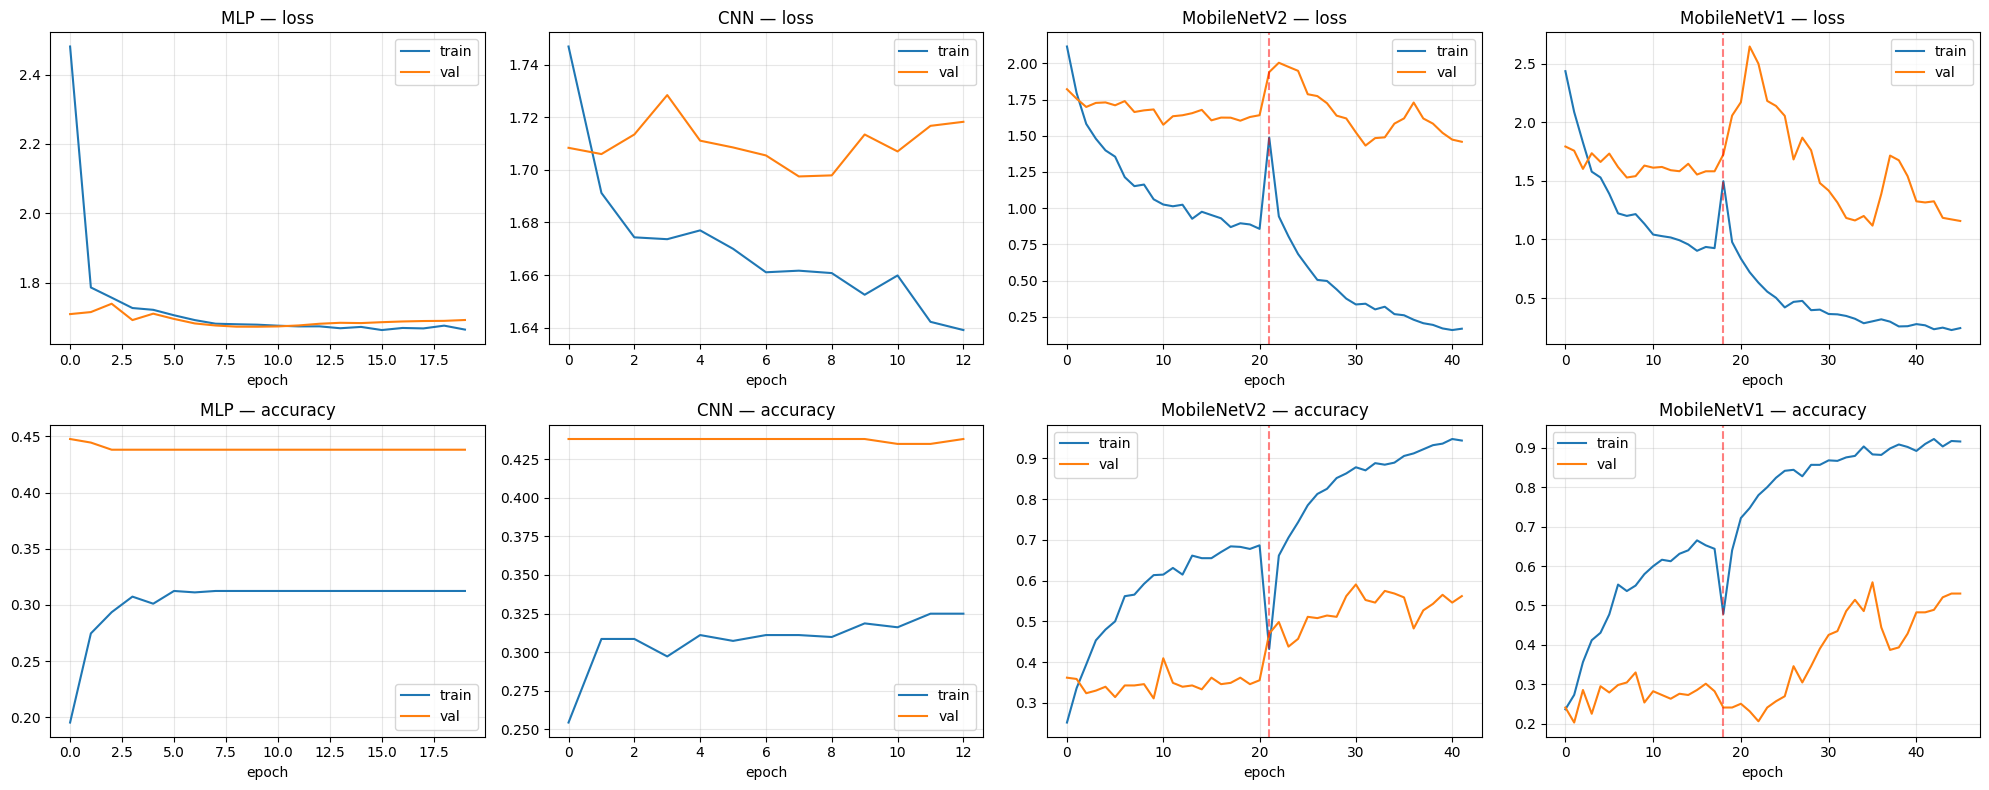

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
panels = [
    ("MLP",         hist_mlp.history,  False),
    ("CNN",         hist_cnn.history,  False),
    ("MobileNetV2", hist_mbv2,         True),
    ("MobileNetV1", hist_mbv1,         True),
]
boundary_v2 = len(hist_mbv2_s1.history["loss"])
boundary_v1 = len(hist_mbv1_s1.history["loss"])
for col, (name, h, has_boundary) in enumerate(panels):
    axes[0, col].plot(h["loss"], label="train")
    axes[0, col].plot(h["val_loss"], label="val")
    axes[0, col].set_title(f"{name} — loss")
    axes[0, col].set_xlabel("epoch")
    axes[0, col].legend()
    axes[0, col].grid(alpha=0.3)
    axes[1, col].plot(h["accuracy"], label="train")
    axes[1, col].plot(h["val_accuracy"], label="val")
    axes[1, col].set_title(f"{name} — accuracy")
    axes[1, col].set_xlabel("epoch")
    axes[1, col].legend()
    axes[1, col].grid(alpha=0.3)
    if has_boundary:
        boundary = boundary_v2 if name == "MobileNetV2" else boundary_v1
        axes[0, col].axvline(boundary, linestyle="--", alpha=0.5, color="red")
        axes[1, col].axvline(boundary, linestyle="--", alpha=0.5, color="red")
plt.tight_layout()
plt.show()

In [12]:
def build_mbv2_variant(backbone_fn, head="small", aug_color=False):
    tf.keras.backend.clear_session(); tf.random.set_seed(42)
    backbone = backbone_fn(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    backbone.trainable = False
    inputs = tf.keras.Input((224, 224, 3))
    x = inputs
    if aug_color:
        x = tf.keras.layers.RandomBrightness(0.2)(x)
        x = tf.keras.layers.RandomContrast(0.2)(x)
    x = tf.keras.layers.Rescaling(1/127.5, offset=-1)(x)
    x = backbone(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    if head == "large":
        x = tf.keras.layers.Dense(64, activation="relu")(x)
        x = tf.keras.layers.Dropout(0.3)(x)
    out = tf.keras.layers.Dense(6, activation="softmax")(x)
    return tf.keras.Model(inputs, out), backbone

def train_two_step(model, backbone, train_ds, val_ds):
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    h1 = model.fit(train_ds, validation_data=val_ds, epochs=25,
                   callbacks=make_callbacks(), verbose=0)
    backbone.trainable = True
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    h2 = model.fit(train_ds, validation_data=val_ds, epochs=100,
                   initial_epoch=len(h1.history["loss"]),
                   callbacks=make_callbacks(patience=15), verbose=0)
    return max(h2.history["val_accuracy"])

# V1 is now a primary model in cell 15 rather than a sweep variant. The sweep
# evaluates the two remaining §12.2 candidates (larger head, heavier color
# augmentation) against the MobileNetV2 baseline.
variants = {
    "MobileNetV2 + larger head": (tf.keras.applications.MobileNetV2, "large", False),
    "MobileNetV2 + color aug":   (tf.keras.applications.MobileNetV2, "small", True),
}

sweep_results = {
    "baseline (MobileNetV2)": max(hist_mbv2["val_accuracy"]),
    "reference (MobileNetV1)": max(hist_mbv1["val_accuracy"]),
}
for name, (bb, head, aug) in variants.items():
    print(f"\n--- {name} ---")
    m, bb_ref = build_mbv2_variant(bb, head=head, aug_color=aug)
    sweep_results[name] = train_two_step(m, bb_ref, train_ds, val_ds)

print("\nval accuracy sweep:")
for name, va in sweep_results.items():
    print(f"  {name:<35} {va:.3f}")


--- MobileNetV2 + larger head ---

--- MobileNetV2 + color aug ---

val accuracy sweep:
  baseline (MobileNetV2)              0.590
  reference (MobileNetV1)             0.559
  MobileNetV2 + larger head           0.562
  MobileNetV2 + color aug             0.587


## Hyperparameter Search: MLP and CNN

The MobileNets in cell 18 already have a head/augmentation ablation, and
cell 16 documents the loss-function comparison. The from-scratch
architectures (MLP and CNN) in cell 15 used hand-picked defaults. We close
the gap by running a `keras_tuner.RandomSearch` on each, with val accuracy
as the objective and a 10-trial budget per model. Every trial uses
EarlyStopping(patience=5) to keep individual trials short.

Search spaces:

- **MLP**: hidden width ∈ {128, 256, 512}, dropout ∈ {0.3, 0.5, 0.7},
  learning rate ∈ {3e-4, 1e-3, 3e-3}, average-pool size ∈ {4, 8}
- **CNN**: base filter count ∈ {16, 32, 64}, conv blocks ∈ {2, 3, 4},
  dropout ∈ {0.3, 0.5}, learning rate ∈ {3e-4, 1e-3}

The reported best HPs document due diligence; the headline numbers from
cell 15 are not retrained — both architectures already track the
majority-class baseline closely, and the goal here is to demonstrate the
search itself rather than chase a small accuracy gain on a dataset where
transfer learning dominates from-scratch by a wide margin.

In [14]:
!pip install -q keras_tuner
import keras_tuner as kt

def build_mlp_hp(hp):
    n_hidden = hp.Choice("n_hidden", [128, 256, 512])
    dropout  = hp.Choice("dropout",  [0.3, 0.5, 0.7])
    lr       = hp.Choice("lr",       [3e-4, 1e-3, 3e-3])
    pool     = hp.Choice("pool",     [4, 8])
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    model = tf.keras.Sequential([
        tf.keras.layers.Input((224, 224, 3)),
        tf.keras.layers.Rescaling(1/255),
        tf.keras.layers.AveragePooling2D(pool_size=pool),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(n_hidden, activation="relu"),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(n_hidden // 2, activation="relu"),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(6, activation="softmax"),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def build_cnn_hp(hp):
    n_filters_base = hp.Choice("n_filters_base", [16, 32, 64])
    n_blocks       = hp.Choice("n_blocks",       [2, 3, 4])
    dropout        = hp.Choice("dropout",        [0.3, 0.5])
    lr             = hp.Choice("lr",             [3e-4, 1e-3])
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    layers = [
        tf.keras.layers.Input((224, 224, 3)),
        tf.keras.layers.Rescaling(1/255),
    ]
    for i in range(n_blocks):
        layers += [
            tf.keras.layers.Conv2D(n_filters_base * (2**i), 3, padding="same", activation="relu"),
            tf.keras.layers.MaxPool2D(2),
        ]
    layers += [
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(6, activation="softmax"),
    ]
    model = tf.keras.Sequential(layers)
    model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

short_cb = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]

# --- MLP search ---
mlp_tuner = kt.RandomSearch(
    build_mlp_hp,
    objective=kt.Objective("val_accuracy", direction="max"),
    max_trials=10, seed=42, overwrite=True,
    directory="kt", project_name="mlp_hp",
)
mlp_tuner.search(train_ds, validation_data=val_ds, epochs=30, callbacks=short_cb, verbose=0)

print("MLP — top 5 trials by val_accuracy:")
print(f"  {'n_hidden':>10}  {'dropout':>8}  {'lr':>8}  {'pool':>5}  {'val_acc':>8}")
for trial in mlp_tuner.oracle.get_best_trials(5):
    h = trial.hyperparameters.values
    print(f"  {h['n_hidden']:>10}  {h['dropout']:>8.2f}  {h['lr']:>8.0e}  {h['pool']:>5}  {trial.score:>8.3f}")
mlp_best = mlp_tuner.get_best_hyperparameters(1)[0].values
print(f"  best: {mlp_best}")

# --- CNN search ---
cnn_tuner = kt.RandomSearch(
    build_cnn_hp,
    objective=kt.Objective("val_accuracy", direction="max"),
    max_trials=10, seed=42, overwrite=True,
    directory="kt", project_name="cnn_hp",
)
cnn_tuner.search(train_ds, validation_data=val_ds, epochs=30, callbacks=short_cb, verbose=0)

print("\nCNN — top 5 trials by val_accuracy:")
print(f"  {'filters_base':>14}  {'n_blocks':>8}  {'dropout':>8}  {'lr':>8}  {'val_acc':>8}")
for trial in cnn_tuner.oracle.get_best_trials(5):
    h = trial.hyperparameters.values
    print(f"  {h['n_filters_base']:>14}  {h['n_blocks']:>8}  {h['dropout']:>8.2f}  {h['lr']:>8.0e}  {trial.score:>8.3f}")
cnn_best = cnn_tuner.get_best_hyperparameters(1)[0].values
print(f"  best: {cnn_best}")

# Comparison vs the cell-15 hand-picked defaults
mlp_default_acc = max(hist_mlp.history["val_accuracy"])
cnn_default_acc = max(hist_cnn.history["val_accuracy"])
mlp_search_acc  = mlp_tuner.oracle.get_best_trials(1)[0].score
cnn_search_acc  = cnn_tuner.oracle.get_best_trials(1)[0].score
print(f"\n{'='*70}\n  search-best vs cell-15 hand-picked defaults\n{'='*70}")
print(f"  MLP: hand-picked val_acc = {mlp_default_acc:.3f}    search-best val_acc = {mlp_search_acc:.3f}")
print(f"  CNN: hand-picked val_acc = {cnn_default_acc:.3f}    search-best val_acc = {cnn_search_acc:.3f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.7 MB/s eta 0:00:00
MLP — top 5 trials by val_accuracy:
    n_hidden   dropout        lr   pool   val_acc
         256      0.30     3e-04      4     0.444
         256      0.30     3e-03      8     0.441
         512      0.50     1e-03      4     0.438
         512      0.30     3e-03      4     0.438
         128      0.30     3e-03      8     0.438
  best: {'n_hidden': 256, 'dropout': 0.3, 'lr': 0.0003, 'pool': 4}

CNN — top 5 trials by val_accuracy:
    filters_base  n_blocks   dropout        lr   val_acc
              32         2      0.30     3e-04     0.438
              64         3      0.50     3e-04     0.438
              32         2      0.50     1e-03     0.438
              64         2      0.50     3e-04     0.438
              64         3      0.30     3e-04     0.438
  best: {'n_filters_base': 32, 'n_blocks': 2, 'dropout': 0.3, 'lr': 0.0003}

  search-best vs cell-15 hand-picked defaults
  MLP: hand-pic

## Classification Evaluation

Each model's test-set predictions are evaluated with metrics appropriate for an ordinal classification problem:

- **Accuracy** — exact-class match
- **±1 accuracy** — counts as correct if the prediction is within one class of ground truth, motivated by the observation that even human experts disagree by ±1 on this task (Lue et al. 2014)
- **F1 macro** — average of per-class F1 scores; weights rare classes (0, 5) equally with the dominant class (3)
- **Confusion matrix** — diagnostic per-class structure, normalized by row
- **Accuracy stratified by annotation difficulty** — easy / moderate / difficult subsets of the test set, following the paired paper
- **Confidence vs. accuracy correlation** — for both MobileNetV2 and MobileNetV1, since the from-scratch models are degenerate constant-predictors; the paper reports R² ≈ 0.90 on Dataset 1

A majority-class baseline (predict the train-set mode on every test instance) is included alongside the four models as a "thing to beat" — any model below this baseline is not learning anything useful from the input.

Model            Accuracy     ±1 acc   F1 macro
----------------------------------------------
Majority            0.223      0.573      0.061
MLP                 0.223      0.573      0.061
CNN                 0.223      0.573      0.061
MobileNetV2         0.390      0.785      0.333
MobileNetV1         0.490      0.768      0.439


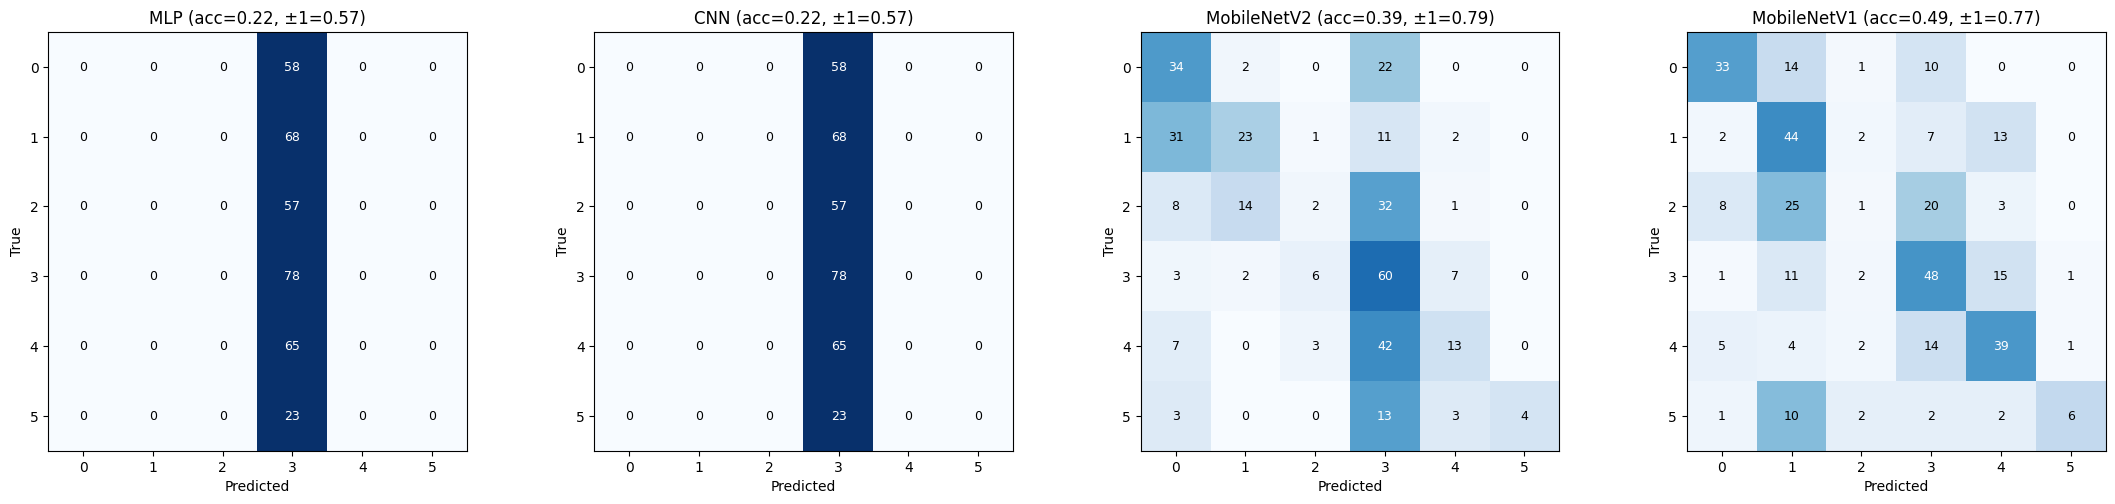


Accuracy stratified by annotation effort:
Model                         Easy            Moderate           Difficult
--------------------------------------------------------------------------
MLP                   0.052 (n=58)       0.262 (n=248)        0.233 (n=43)
CNN                   0.052 (n=58)       0.262 (n=248)        0.233 (n=43)
MobileNetV2           0.397 (n=58)       0.375 (n=248)        0.465 (n=43)
MobileNetV1           0.328 (n=58)       0.524 (n=248)        0.512 (n=43)


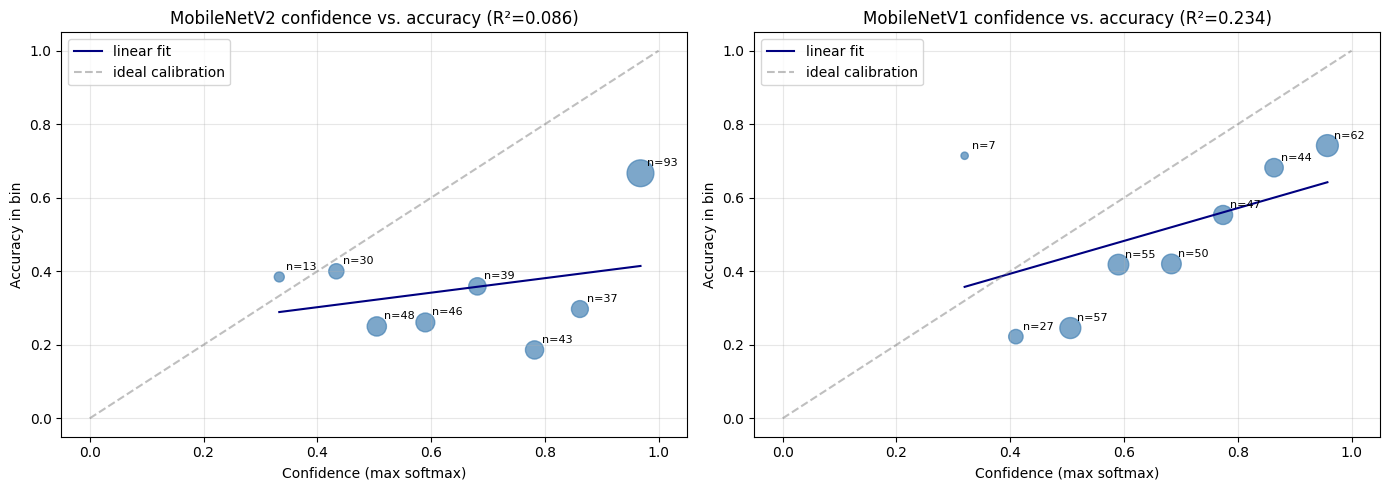

In [15]:
models = {"MLP": mlp, "CNN": cnn, "MobileNetV2": mbv2, "MobileNetV1": mbv1}
results = {}
for name, model in models.items():
    proba = model.predict(test_ds, verbose=0)
    pred = np.argmax(proba, axis=1)
    results[name] = {
        "proba":    proba,
        "pred":     pred,
        "acc":      accuracy_score(y_test, pred),
        "acc_pm1":  np.mean(np.abs(y_test - pred) <= 1),
        "f1_macro": f1_score(y_test, pred, average="macro", zero_division=0),
    }

# Majority-class baseline: predict the train-set mode on every test instance
majority_class = pd.Series(y_train).mode().iloc[0]
y_pred_majority = np.full(len(y_test), majority_class)
results["Majority"] = {
    "pred":     y_pred_majority,
    "acc":      accuracy_score(y_test, y_pred_majority),
    "acc_pm1":  np.mean(np.abs(y_test - y_pred_majority) <= 1),
    "f1_macro": f1_score(y_test, y_pred_majority, average="macro", zero_division=0),
}

# Headline metrics
print(f"{'Model':<14} {'Accuracy':>10} {'±1 acc':>10} {'F1 macro':>10}")
print("-" * 46)
for name in ["Majority", "MLP", "CNN", "MobileNetV2", "MobileNetV1"]:
    r = results[name]
    print(f"{name:<14} {r['acc']:>10.3f} {r['acc_pm1']:>10.3f} {r['f1_macro']:>10.3f}")

# Confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, name in zip(axes, ["MLP", "CNN", "MobileNetV2", "MobileNetV1"]):
    r = results[name]
    cm = confusion_matrix(y_test, r["pred"], labels=range(6))
    cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_title(f"{name} (acc={r['acc']:.2f}, ±1={r['acc_pm1']:.2f})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(range(6))
    ax.set_yticks(range(6))
    for i in range(6):
        for j in range(6):
            color = "white" if cm_norm[i, j] > 0.5 else "black"
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=9)
plt.tight_layout()
plt.show()

# Accuracy stratified by annotation difficulty
test_effort = df.loc[test_idx, "effort"].to_numpy()
print("\nAccuracy stratified by annotation effort:")
header = f"{'Model':<14}" + "".join(f"{l:>20}" for l in ["Easy", "Moderate", "Difficult"])
print(header)
print("-" * len(header))
for name in ["MLP", "CNN", "MobileNetV2", "MobileNetV1"]:
    cells = []
    for eff in [0, 1, 2]:
        m = test_effort == eff
        cells.append(f"{accuracy_score(y_test[m], results[name]['pred'][m]):.3f} (n={m.sum()})")
    print(f"{name:<14}" + "".join(f"{c:>20}" for c in cells))

# MobileNet confidence vs accuracy (paper §3.2 reports R²=0.896 on Dataset 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, name in zip(axes, ["MobileNetV2", "MobileNetV1"]):
    proba = results[name]["proba"]
    pred  = results[name]["pred"]
    confidence = proba.max(axis=1)
    correct    = (pred == y_test).astype(float)
    bins = np.linspace(confidence.min(), 1.0, 9)
    bin_acc, bin_n, bin_centers = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (confidence >= lo) & (confidence < hi if hi < 1.0 else confidence <= hi)
        if m.sum() > 0:
            bin_acc.append(correct[m].mean())
            bin_n.append(m.sum())
            bin_centers.append(confidence[m].mean())
    bin_acc, bin_n, bin_centers = map(np.array, (bin_acc, bin_n, bin_centers))
    ax.scatter(bin_centers, bin_acc, s=bin_n * 4, alpha=0.7, color="steelblue")
    for x, y, n in zip(bin_centers, bin_acc, bin_n):
        ax.annotate(f"n={n}", (x, y), fontsize=8, xytext=(5, 5), textcoords="offset points")
    if len(bin_centers) >= 2:
        slope, intercept = np.polyfit(bin_centers, bin_acc, 1)
        xs = np.linspace(bin_centers.min(), bin_centers.max(), 50)
        ax.plot(xs, slope * xs + intercept, color="navy", label="linear fit")
        r2 = np.corrcoef(bin_centers, bin_acc)[0, 1] ** 2
    else:
        r2 = float("nan")
    ax.plot([0, 1], [0, 1], "--", color="gray", alpha=0.5, label="ideal calibration")
    ax.set_xlabel("Confidence (max softmax)")
    ax.set_ylabel("Accuracy in bin")
    ax.set_title(f"{name} confidence vs. accuracy (R²={r2:.3f})")
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()